# Preprocessing Comparison: Percentile Pooling Results

This notebook visualizes the results from the three-way preprocessing comparison experiment using **percentile pooling** (10th, 25th, 50th, 75th, 90th percentiles → 1,920-dim features).

## Preprocessing Strategies Compared:
1. **Baseline**: Full-volume, no lesion filtering
2. **Filtered**: Full-volume with lesion size filtering (min_voxels=300, min_dimension=5, min_density=0.1)
3. **ROI-Cropped**: Adaptive crop/pad with 30-voxel margin

All experiments use:
- TabPFN classifier
- 5-fold cross-validation
- Percentile pooling strategy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

## 1. Load Results

In [2]:
# Load the latest results CSV
results_path = Path('../../results/preprocessing_comparison/preprocessing_comparison_latest.csv')
df = pd.read_csv(results_path)

print("Results loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nDatasets: {df['dataset'].tolist()}")
df.head()

Results loaded successfully!
Shape: (6, 16)

Datasets: ['crlm', 'desmoid', 'gist', 'lipo', 'liver', 'melanoma']


,dataset,accuracy_baseline,macro_f1_baseline,roc_auc_baseline,accuracy_filtered,macro_f1_filtered,roc_auc_filtered,accuracy_roi,macro_f1_roi,roc_auc_roi,accuracy_delta_filtered,macro_f1_delta_filtered,roc_auc_delta_filtered,accuracy_delta_roi,macro_f1_delta_roi,roc_auc_delta_roi
0,crlm,0.508333,0.463733,0.491071,NaN,NaN,NaN,0.508333,0.463733,0.491071,NaN,NaN,NaN,0.0,0.0,0.0
1,desmoid,0.694390,0.612637,0.658555,0.711429,0.414573,0.503333,0.694390,0.612637,0.658555,0.017038,-0.198064,-0.155222,0.0,0.0,0.0
2,gist,0.609306,0.607005,0.653733,0.648485,0.614153,0.762963,0.609306,0.607005,0.653733,0.039179,0.007148,0.109230,0.0,0.0,0.0
3,lipo,0.504348,0.496553,0.465909,0.471324,0.401190,0.363194,0.504348,0.496553,0.465909,-0.033024,-0.095363,-0.102715,0.0,0.0,0.0
4,liver,0.596728,0.591660,0.605417,0.666667,0.399560,0.511111,0.596728,0.591660,0.605417,0.069938,-0.192100,-0.094306,0.0,0.0,0.0


## 2. Data Processing & Summary Statistics

In [3]:
# Calculate summary statistics
metrics = ['accuracy', 'macro_f1', 'roc_auc']
preprocessing_types = ['baseline', 'filtered', 'roi']

summary_stats = {}
for preproc in preprocessing_types:
    summary_stats[preproc] = {
        metric: {
            'mean': df[f'{metric}_{preproc}'].mean(),
            'std': df[f'{metric}_{preproc}'].std(),
            'min': df[f'{metric}_{preproc}'].min(),
            'max': df[f'{metric}_{preproc}'].max()
        }
        for metric in metrics
    }

# Display summary
summary_df = pd.DataFrame({
    (preproc, metric): f"{stats['mean']:.4f} ± {stats['std']:.4f}"
    for preproc in preprocessing_types
    for metric, stats in summary_stats[preproc].items()
}, index=[0]).T

summary_df.columns = ['Mean ± Std']
print("\n" + "="*60)
print("SUMMARY STATISTICS (Percentile Pooling)")
print("="*60)
print(summary_df)
print("="*60)


SUMMARY STATISTICS (Percentile Pooling)
                        Mean ± Std
baseline accuracy  0.5648 ± 0.0832
         macro_f1  0.5389 ± 0.0725
         roc_auc   0.5668 ± 0.0837
filtered accuracy  0.6262 ± 0.0914
         macro_f1  0.4726 ± 0.0969
         roc_auc   0.5881 ± 0.1865
roi      accuracy  0.5648 ± 0.0832
         macro_f1  0.5389 ± 0.0725
         roc_auc   0.5668 ± 0.0837


## 3. Key Findings & Observations

In [4]:
# Calculate improvements
print("\n" + "="*60)
print("IMPROVEMENTS vs BASELINE")
print("="*60)

for preproc in ['filtered', 'roi']:
    print(f"\n{preproc.upper()}:")
    for metric in metrics:
        baseline_mean = summary_stats['baseline'][metric]['mean']
        preproc_mean = summary_stats[preproc][metric]['mean']
        improvement = preproc_mean - baseline_mean
        pct_improvement = (improvement / baseline_mean) * 100 if baseline_mean != 0 else 0
        
        sign = '+' if improvement >= 0 else ''
        print(f"  {metric:12s}: {sign}{improvement:.4f} ({sign}{pct_improvement:.2f}%)")

print("="*60)


IMPROVEMENTS vs BASELINE

FILTERED:
  accuracy    : +0.0614 (+10.88%)
  macro_f1    : -0.0663 (-12.30%)
  roc_auc     : +0.0214 (+3.77%)

ROI:
  accuracy    : +0.0000 (+0.00%)
  macro_f1    : +0.0000 (+0.00%)
  roc_auc     : +0.0000 (+0.00%)


In [5]:
# Check which datasets have filtered results (crlm is missing)
print("\nDatasets with filtered results:")
filtered_mask = df['accuracy_filtered'].notna()
print(df[filtered_mask][['dataset', 'accuracy_filtered', 'macro_f1_filtered', 'roc_auc_filtered']])


Datasets with filtered results:
    dataset  accuracy_filtered  macro_f1_filtered  roc_auc_filtered
1   desmoid           0.711429           0.414573          0.503333
2      gist           0.648485           0.614153          0.762963
3      lipo           0.471324           0.401190          0.363194
4     liver           0.666667           0.399560          0.511111
5  melanoma           0.633333           0.533333          0.800000


## 4. Visualization: Metric Comparison Across Preprocessing Strategies

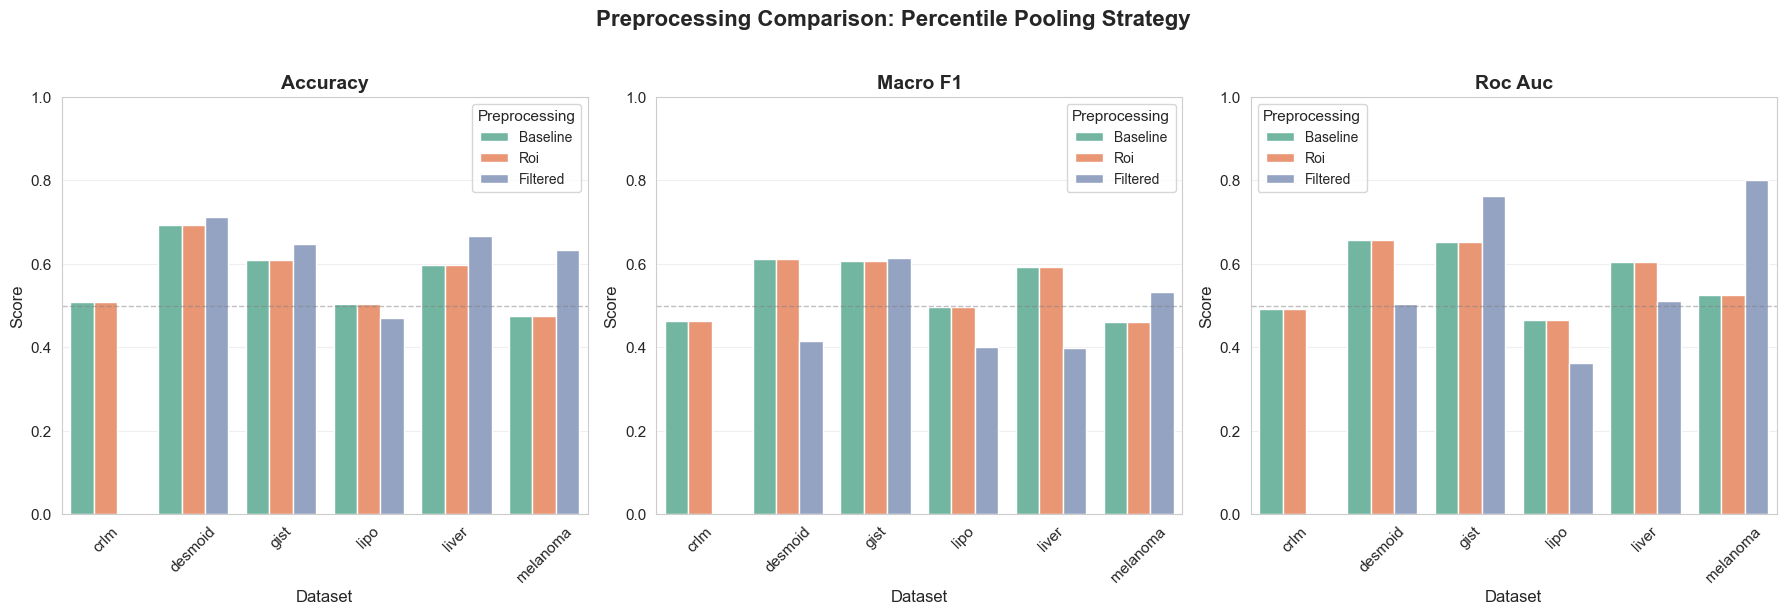

In [6]:
# Reshape data for plotting
plot_data = []
for _, row in df.iterrows():
    dataset = row['dataset']
    for preproc in preprocessing_types:
        for metric in metrics:
            value = row[f'{metric}_{preproc}']
            if pd.notna(value):
                plot_data.append({
                    'Dataset': dataset,
                    'Preprocessing': preproc.capitalize(),
                    'Metric': metric.replace('_', ' ').title(),
                    'Value': value
                })

plot_df = pd.DataFrame(plot_data)

# Create figure with subplots for each metric
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Preprocessing Comparison: Percentile Pooling Strategy', fontsize=16, fontweight='bold', y=1.02)

for idx, metric_name in enumerate(['Accuracy', 'Macro F1', 'Roc Auc']):
    ax = axes[idx]
    metric_data = plot_df[plot_df['Metric'] == metric_name]
    
    sns.barplot(
        data=metric_data,
        x='Dataset',
        y='Value',
        hue='Preprocessing',
        ax=ax,
        palette='Set2'
    )
    
    ax.set_title(metric_name, fontsize=14, fontweight='bold')
    ax.set_xlabel('Dataset', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_ylim(0, 1.0)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.legend(title='Preprocessing', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    
    # Rotate x-axis labels
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Per-Dataset Analysis

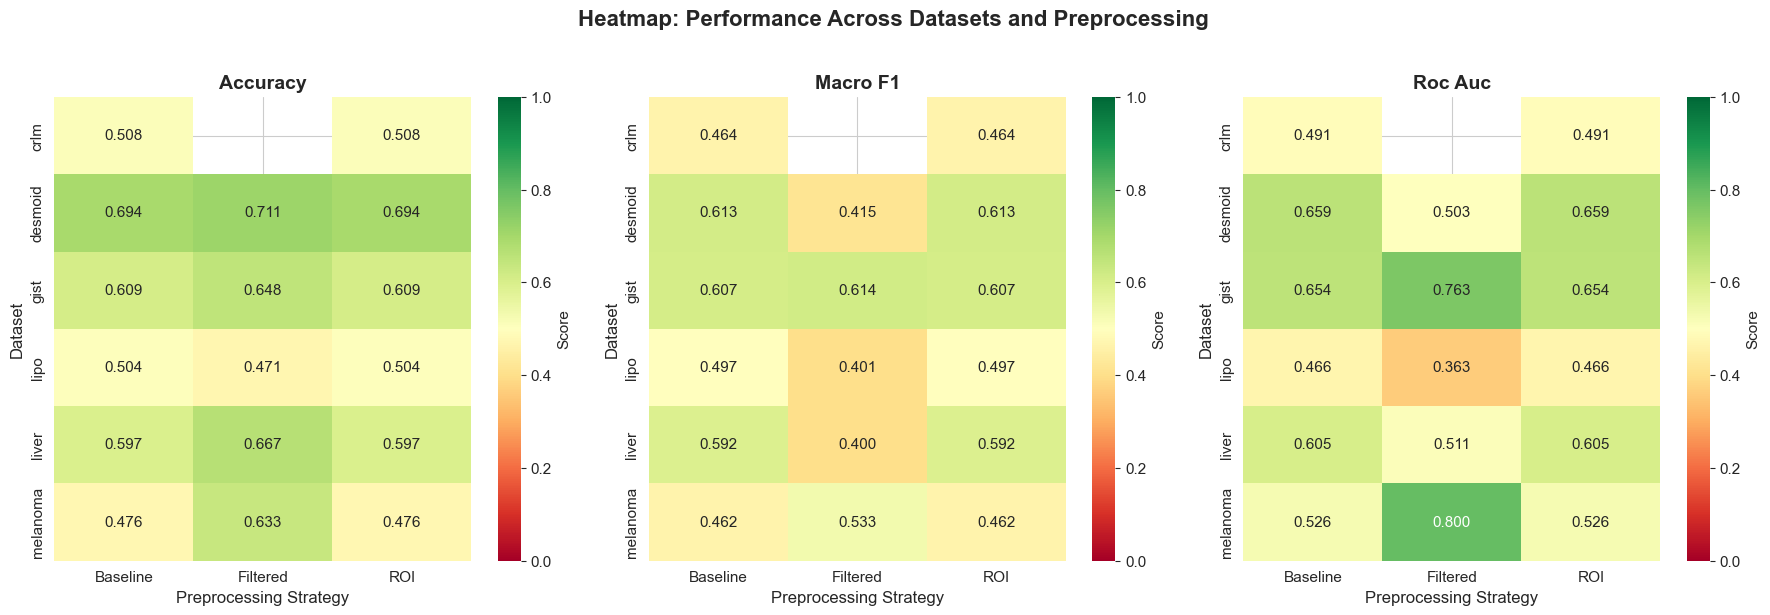

In [7]:
# Create heatmap for all metrics and preprocessing strategies
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Heatmap: Performance Across Datasets and Preprocessing', fontsize=16, fontweight='bold', y=1.02)

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    # Create pivot table
    pivot_data = df.pivot_table(
        index='dataset',
        values=[f'{metric}_baseline', f'{metric}_filtered', f'{metric}_roi'],
        aggfunc='first'
    )
    pivot_data.columns = ['Baseline', 'Filtered', 'ROI']
    
    # Plot heatmap
    sns.heatmap(
        pivot_data,
        annot=True,
        fmt='.3f',
        cmap='RdYlGn',
        vmin=0,
        vmax=1,
        center=0.5,
        cbar_kws={'label': 'Score'},
        ax=ax
    )
    
    ax.set_title(metric.replace('_', ' ').title(), fontsize=14, fontweight='bold')
    ax.set_xlabel('Preprocessing Strategy', fontsize=12)
    ax.set_ylabel('Dataset', fontsize=12)

plt.tight_layout()
plt.show()

## 6. Delta Analysis: Change from Baseline

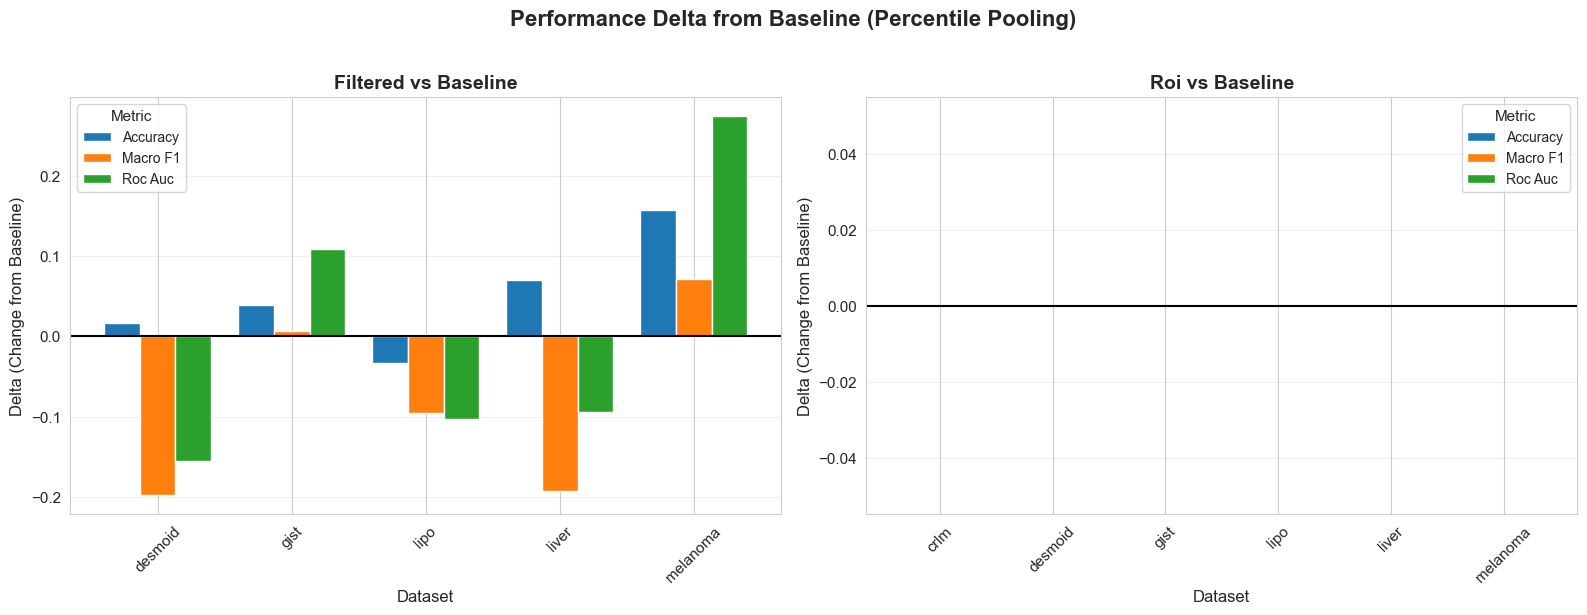

In [8]:
# Plot delta improvements
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Performance Delta from Baseline (Percentile Pooling)', fontsize=16, fontweight='bold', y=1.02)

preprocessing_deltas = ['filtered', 'roi']
for idx, preproc in enumerate(preprocessing_deltas):
    ax = axes[idx]
    
    # Prepare delta data
    delta_data = []
    for _, row in df.iterrows():
        if pd.notna(row[f'accuracy_delta_{preproc}']):
            for metric in metrics:
                delta_data.append({
                    'Dataset': row['dataset'],
                    'Metric': metric.replace('_', ' ').title(),
                    'Delta': row[f'{metric}_delta_{preproc}']
                })
    
    delta_df = pd.DataFrame(delta_data)
    
    # Pivot for grouped bar plot
    pivot_delta = delta_df.pivot(index='Dataset', columns='Metric', values='Delta')
    
    pivot_delta.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e', '#2ca02c'], width=0.8)
    ax.set_title(f'{preproc.capitalize()} vs Baseline', fontsize=14, fontweight='bold')
    ax.set_xlabel('Dataset', fontsize=12)
    ax.set_ylabel('Delta (Change from Baseline)', fontsize=12)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
    ax.legend(title='Metric', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Lesion Filtering Impact Analysis

In [9]:
# Display lesion filtering statistics from log
filtering_stats = {
    'Dataset': ['crlm', 'desmoid', 'gist', 'lipo', 'liver', 'melanoma'],
    'Viable Cases': [5, 73, 108, 81, 42, 11],
    'Total Cases': [77, 203, 246, 115, 186, 103],
    'Retention Rate (%)': [6.5, 36.0, 43.9, 70.4, 22.6, 10.7]
}
filtering_df = pd.DataFrame(filtering_stats)
filtering_df['Filtered Out'] = filtering_df['Total Cases'] - filtering_df['Viable Cases']

print("\n" + "="*70)
print("LESION SIZE FILTERING IMPACT")
print("Criteria: min_voxels=300, min_dimension=5, min_density=0.1")
print("="*70)
print(filtering_df.to_string(index=False))
print("="*70)
print(f"\nTotal viable cases: {filtering_df['Viable Cases'].sum()}/{filtering_df['Total Cases'].sum()} "
      f"({filtering_df['Viable Cases'].sum() / filtering_df['Total Cases'].sum() * 100:.1f}%)")
print(f"Total filtered out: {filtering_df['Filtered Out'].sum()}")


LESION SIZE FILTERING IMPACT
Criteria: min_voxels=300, min_dimension=5, min_density=0.1
 Dataset  Viable Cases  Total Cases  Retention Rate (%)  Filtered Out
    crlm             5           77                 6.5            72
 desmoid            73          203                36.0           130
    gist           108          246                43.9           138
    lipo            81          115                70.4            34
   liver            42          186                22.6           144
melanoma            11          103                10.7            92

Total viable cases: 320/930 (34.4%)
Total filtered out: 610


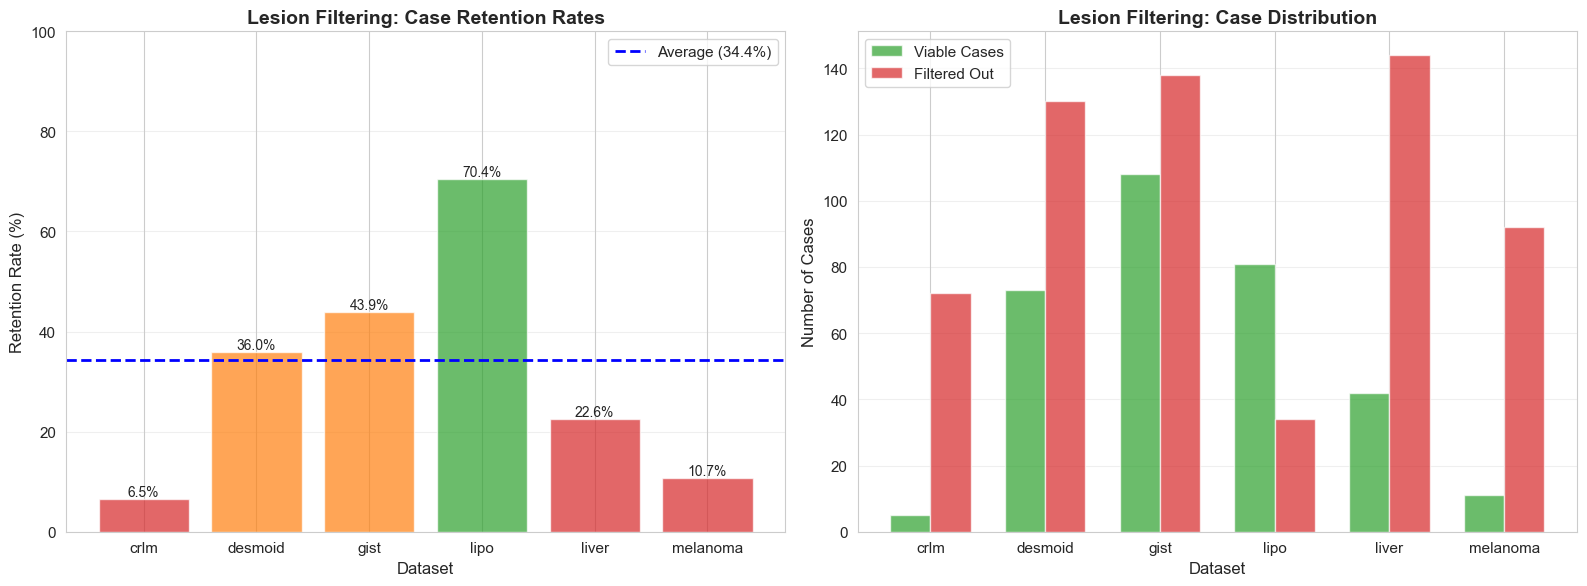

In [10]:
# Visualize filtering impact
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Retention rates
ax1 = axes[0]
colors = ['#d62728' if x < 30 else '#ff7f0e' if x < 50 else '#2ca02c' 
          for x in filtering_df['Retention Rate (%)']]
bars = ax1.bar(filtering_df['Dataset'], filtering_df['Retention Rate (%)'], color=colors, alpha=0.7)
ax1.set_title('Lesion Filtering: Case Retention Rates', fontsize=14, fontweight='bold')
ax1.set_xlabel('Dataset', fontsize=12)
ax1.set_ylabel('Retention Rate (%)', fontsize=12)
ax1.axhline(y=34.4, color='blue', linestyle='--', label='Average (34.4%)', linewidth=2)
ax1.set_ylim(0, 100)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

# Right plot: Viable vs filtered out
ax2 = axes[1]
x = np.arange(len(filtering_df))
width = 0.35
ax2.bar(x - width/2, filtering_df['Viable Cases'], width, label='Viable Cases', color='#2ca02c', alpha=0.7)
ax2.bar(x + width/2, filtering_df['Filtered Out'], width, label='Filtered Out', color='#d62728', alpha=0.7)
ax2.set_title('Lesion Filtering: Case Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Dataset', fontsize=12)
ax2.set_ylabel('Number of Cases', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(filtering_df['Dataset'])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Export summary table
output_path = Path('../../results/preprocessing_comparison/percentile_pooling_summary.csv')
df.to_csv(output_path, index=False)
print(f"\nSummary exported to: {output_path}")


Summary exported to: ..\..\results\preprocessing_comparison\percentile_pooling_summary.csv
